In [89]:
# ==== Cohort Binder (DO NOT MODIFY) ==== 
import hashlib, json, random, numpy as np, datetime, os 
import matplotlib.pyplot as plt 
STUDENT_NAME = input("Enter your full name: ").strip() 
ROLL_NO      = input("Enter your college roll number: ").strip() 
SALT         = "AIML_Capstone_2026"   # fixed by instructor 
sig_str = json.dumps({"n": STUDENT_NAME, "r": ROLL_NO, "s": SALT}) 
STUDENT_SIG = hashlib.sha256(sig_str.encode()).hexdigest()[:12] 
SEED = int(STUDENT_SIG[:8], 16) % (2**31-1) 
random.seed(SEED) 
np.random.seed(SEED) 
TODAY = datetime.date.today().isoformat() 
OUT_PREFIX = f"AIML_{STUDENT_SIG}_{TODAY}" 
os.makedirs("out", exist_ok=True) 
def stamp_plot(title): 
    plt.title(f"{title}\nSIG:{STUDENT_SIG} DATE:{TODAY}") 
print(f"Student: {STUDENT_NAME} | College Roll No: {ROLL_NO}") 
print(f"Signature: {STUDENT_SIG} | Seed: {SEED}") 
print(f"Output prefix: out/{OUT_PREFIX}_*") 

Student: GADAMSETTY NAGA MANIKANTA THARUN | College Roll No: 24UCS123
Signature: c5c95b70276e | Seed: 1170824049
Output prefix: out/AIML_c5c95b70276e_2026-10-02_*


In [90]:
#import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
#Now let us import the data
train_data=pd.read_csv(
    "Dataset File/adult.data",
    header=None,#this will be used when the datset does not start with columns
    skipinitialspace=True#this is used when there are spaces after commas
    )
test_data=pd.read_csv(
    "Dataset File/adult.test",
    header=None,
    skiprows=1,#as the first row is some random heading this line will help to skip it
    skipinitialspace=True
    )

In [92]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week",
    "native_country", "income"
]
#as there are no column names we need to add the specific column names to both training and testing data
train_data.columns = columns
test_data.columns = columns

In [93]:
#for removing the '.' after <=50 statement
test_data["income"] = test_data["income"].str.replace(".", "", regex=False)

In [94]:
#now join both training and testing data
#adult_data = pd.concat([train_data, test_data], ignore_index=True)#this will arrange the indexes clearly

In [95]:
train_data.head(20)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [96]:
print(train_data.shape)
print(test_data.shape)

(32561, 15)
(16281, 15)


In [97]:
print(train_data.info())
print("\n")
print(test_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
None


<class 'pandas.DataFrame'>
RangeIndex: 16281 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column         

In [98]:
#there are '?' symbol replace them with null values using np.nan and replace function
train_data.replace('?',np.nan,inplace=True)
train_data.info()
test_data.replace('?',np.nan,inplace=True)
test_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
<class 'pandas.DataFrame'>
RangeIndex: 16281 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Nu

In [99]:
#now let us check if there are any missing values
print(train_data.isnull().sum())
print(test_data.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64
age                 0
workclass         963
fnlwgt              0
education           0
education_num       0
marital_status      0
occupation        966
relationship        0
race                0
sex                 0
capital_gain        0
capital_loss        0
hours_per_week      0
native_country    274
income              0
dtype: int64


In [100]:
train_data.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [101]:
#Now let us fill the missing values in the respective columns with mode value of the respective column
train_mode = train_data.copy()

train_mode["workclass"]=train_mode["workclass"].fillna(train_mode["workclass"].mode()[0])
train_mode["occupation"]=train_mode["occupation"].fillna(train_mode["occupation"].mode()[0])
train_mode["native_country"]=train_mode["native_country"].fillna(train_mode["native_country"].mode()[0])

In [102]:
#Now let us fill the missing values in the respective columns with mode value of the respective column
test_mode = test_data.copy()

test_mode["workclass"]=test_mode["workclass"].fillna(test_mode["workclass"].mode()[0])
test_mode["occupation"]=test_mode["occupation"].fillna(test_mode["occupation"].mode()[0])
test_mode["native_country"]=test_mode["native_country"].fillna(test_mode["native_country"].mode()[0])

In [103]:
#now let us check for any duplicate rows and remove them
train = train_mode.copy()
print(train.duplicated().sum())
train = train.drop_duplicates()
print(train.duplicated().sum())

24
0


In [104]:
#now let us check for any duplicate rows and remove them
test = test_mode.copy()
print(test.duplicated().sum())
test = test.drop_duplicates()
print(test.duplicated().sum())

5
0


In [105]:
train.shape

(32537, 15)

In [106]:
train.info()

<class 'pandas.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       32537 non-null  str  
 2   fnlwgt          32537 non-null  int64
 3   education       32537 non-null  str  
 4   education_num   32537 non-null  int64
 5   marital_status  32537 non-null  str  
 6   occupation      32537 non-null  str  
 7   relationship    32537 non-null  str  
 8   race            32537 non-null  str  
 9   sex             32537 non-null  str  
 10  capital_gain    32537 non-null  int64
 11  capital_loss    32537 non-null  int64
 12  hours_per_week  32537 non-null  int64
 13  native_country  32537 non-null  str  
 14  income          32537 non-null  str  
dtypes: int64(6), str(9)
memory usage: 4.0 MB


In [107]:
#now as we handled missing values and duplicate rows the data cleaning step is done and now let us divide the columns as numerical
#and categorical columns so that it will be easier to handle data .
numerical_cols=train.select_dtypes(include=["int64"])
categorical_cols=train.select_dtypes(include=["str"])


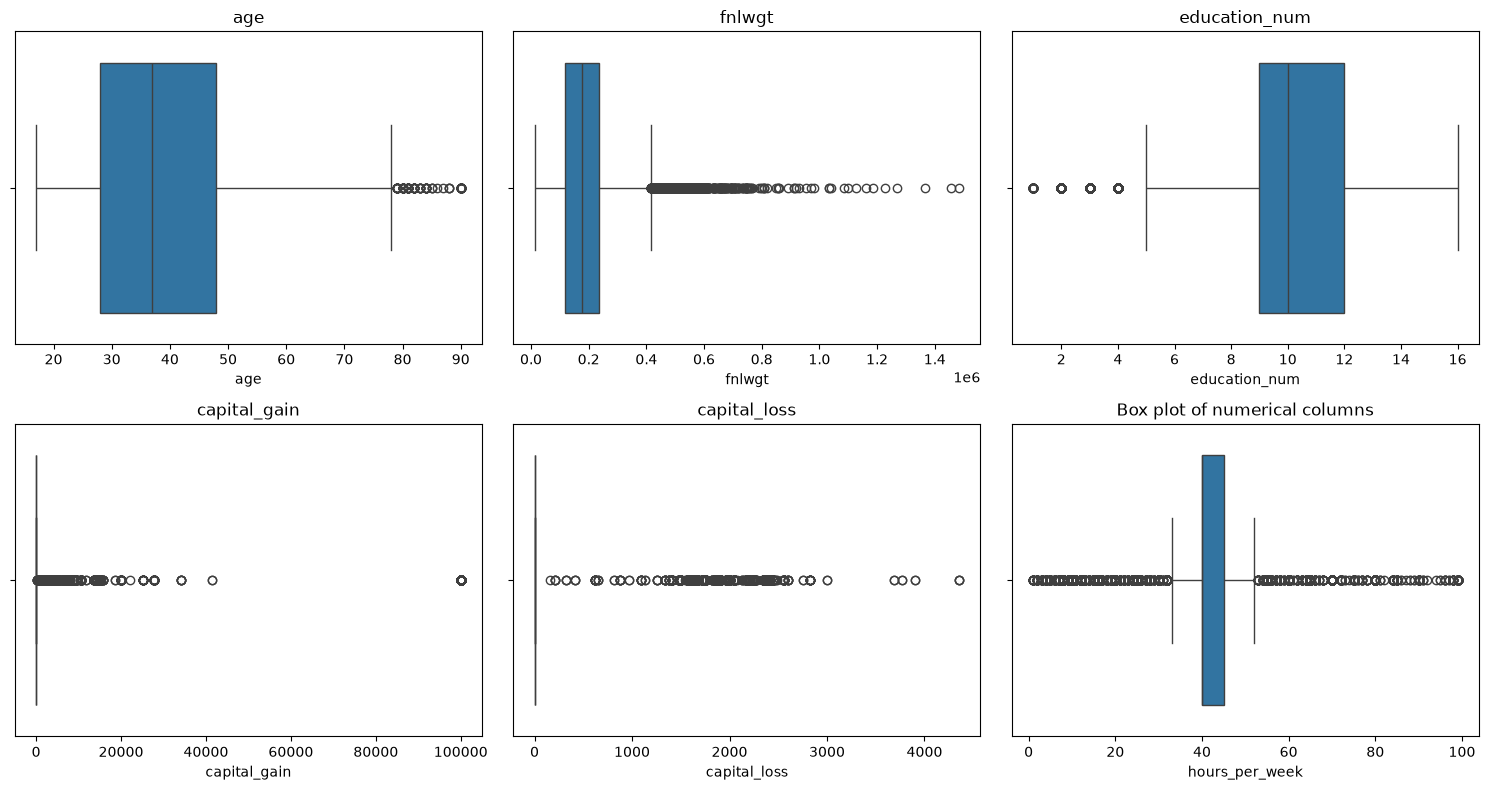

In [108]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(x=train[col], ax=axes[i])
    axes[i].set_title(col)
plt.title("Box plot of numerical columns")
plt.tight_layout()
plt.show()

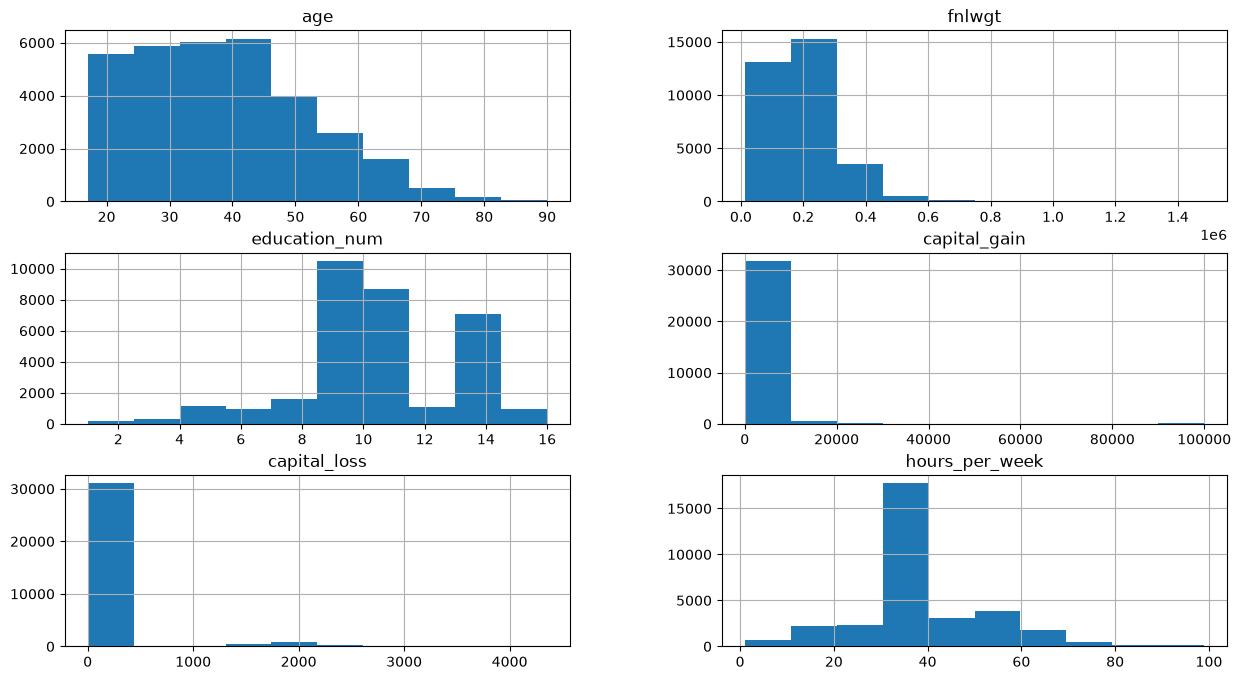

In [109]:
#Even thought there are outliers in numerical columns they are important for prediction because as our data is for classification of income 
numerical_cols=train.select_dtypes(include=["int64"]).columns
train[numerical_cols].hist(figsize=(15,8))
plt.show()

In [110]:
#from above histograms we can say that there are so many people around the age group who are between 20-50 in our data 
#there are more than 30,000 candidates in our data who gained capital in between 0 to 10,000
#there are more than 30,000 candidates in our data who lost capital in between 0-500
#there are more than 25,000 people 30 to 40 hours 
for col in categorical_cols:
    print(f"\n{col}")
    print(train[col].value_counts())


workclass
workclass
Private             24509
Self-emp-not-inc     2540
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

education
education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64

marital_status
marital_status
Married-civ-spouse       14970
Never-married            10667
Divorced                  4441
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

occupation
occupation
Prof-specialty       5979
Craft-repair         40

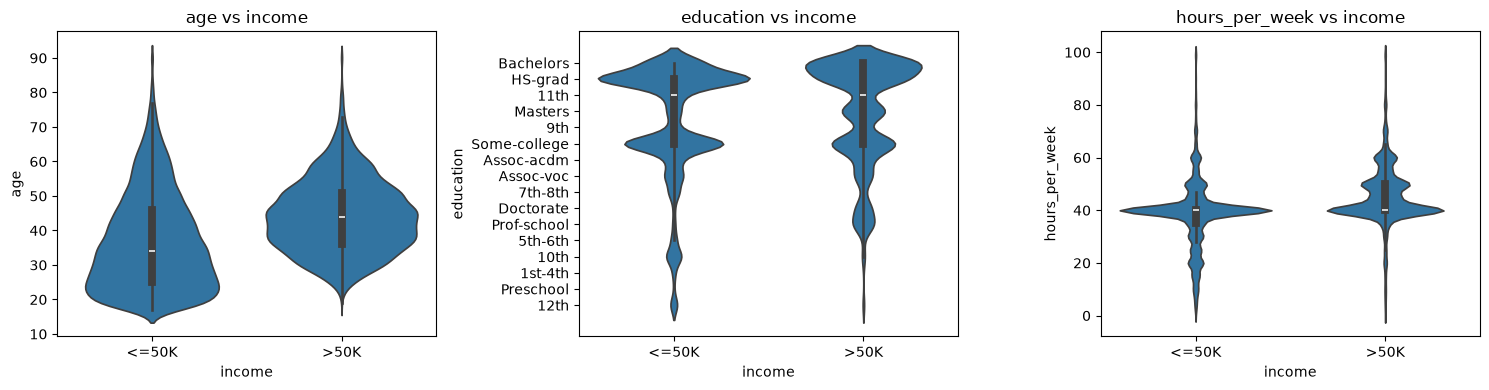

In [111]:
#now let us understand the relationship between age vs income ,education vs income ,hours_per_week vs income by using violin plot,stripplot,KDE plot
numerical=["age","education","hours_per_week"]
categorical=["workclass","occupation"]
target="income"
train_num=train[numerical]

cols = 3
rows = (len(train_num.columns) + cols - 1) // cols

plt.figure(figsize=(5*cols, 4*rows))

for i, col in enumerate(train_num.columns, 1):
    plt.subplot(rows, cols, i)
    sns.violinplot(x=train[target], y=train_num[col])
    plt.title(f"{col} vs {target}")

plt.tight_layout()
plt.show()


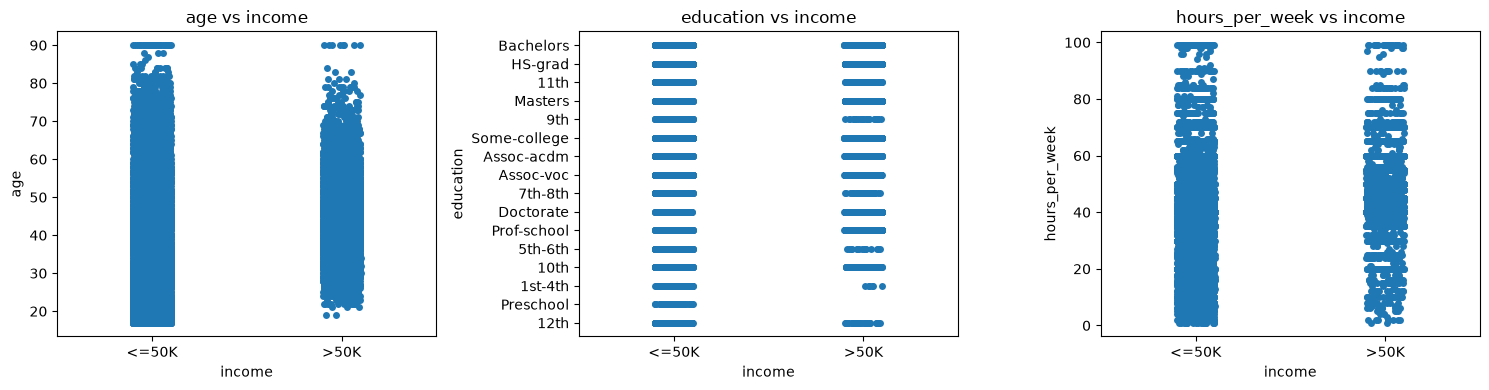

In [112]:
#in the first graph the candidates who are having age between 20-40 are mostly having an income <=50k and candidates whose age is between 30-50 are earning more than 50k 
#from the second graph mostly the candidates are started earning money after their hs-grad and people who completed their masters and doctorate are mostly likely to earn more
#>50k
#the people who are working for atleast 40 hours per week are earning atleast 50k and there are more people who are earning more than 50k who are working more than 40 hours
#week
cols = 3
rows = (len(train_num.columns) + cols - 1) // cols

plt.figure(figsize=(5*cols, 4*rows))

for i, col in enumerate(train_num.columns, 1):
    plt.subplot(rows, cols, i)
    sns.stripplot(x=train[target], y=train_num[col])
    plt.title(f"{col} vs {target}")

plt.tight_layout()
plt.show()


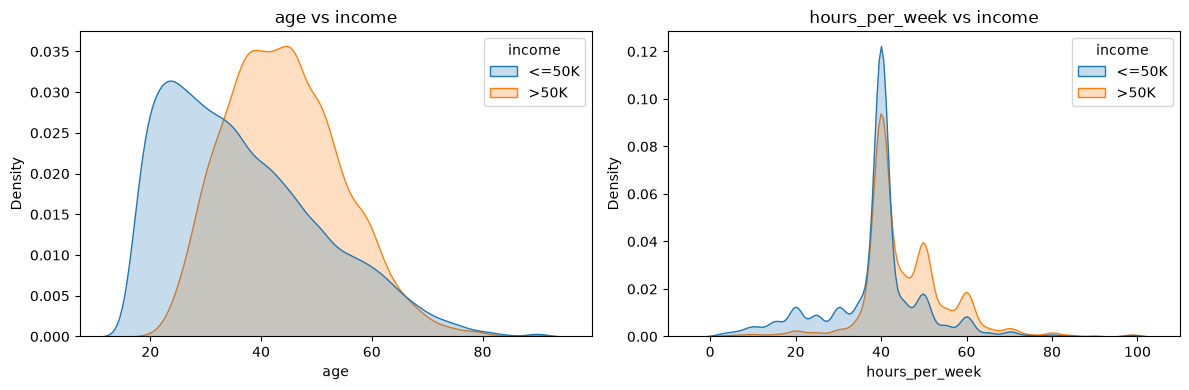

In [113]:
# Select only numerical columns
numerical = ["age", "hours_per_week"]  # use education_num, not education
target = "income"

train_num = train[numerical]

cols = 2
rows = (len(train_num.columns) + cols - 1) // cols

plt.figure(figsize=(6*cols, 4*rows))

for i, col in enumerate(train_num.columns, 1):
    plt.subplot(rows, cols, i)

    sns.kdeplot(
        data=train,
        x=col,
        hue=target,
        fill=True,
        common_norm=False
    )

    plt.title(f"{col} vs {target}")

plt.tight_layout()
plt.show()

In [114]:
#this graphical representations of data is helping us interpret large data easily 

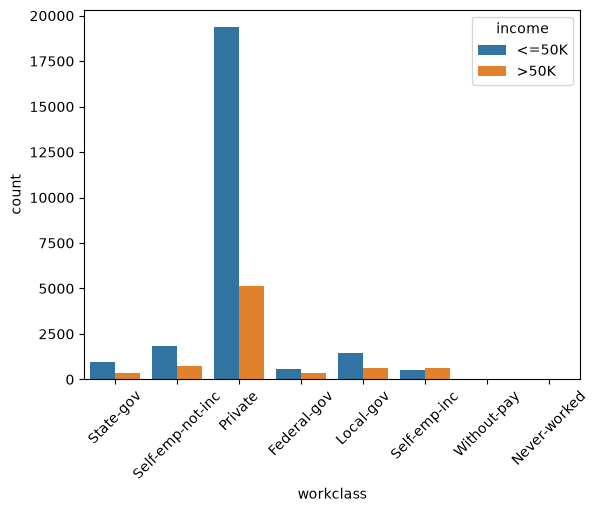

In [115]:
sns.countplot(
    data=train,
    x="workclass",
    hue="income"
)

plt.xticks(rotation=45)
plt.show()

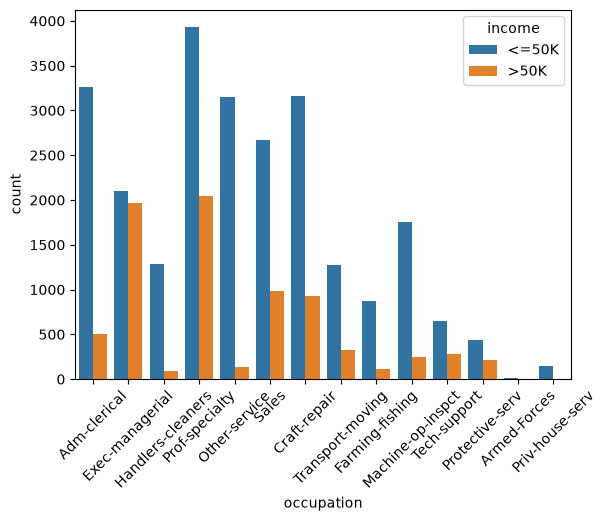

In [116]:
#private sector workclass is <=50k and >50k
sns.countplot(
    data=train,
    x="occupation",
    hue="income"
)

plt.xticks(rotation=45)
plt.show()

In [117]:
#we are going to drop these columns because these are not at all significant for income
train=train.drop(columns=["fnlwgt", "education"])

In [118]:
#we are going to drop these columns because these are not at all significant for income
test=test.drop(columns=["fnlwgt", "education"])

In [119]:
#prof speciality class whose income is more in <=50k and >50k
#now let us seperate the target from train data
X_train=train.drop("income",axis=1)
y_train=train["income"]

In [120]:
X_test=test.drop("income",axis=1)
y_test=test["income"]

In [121]:
categorical_cols = X.select_dtypes(include="object").columns

print(categorical_cols)

Index([], dtype='str')


In [122]:
X_train["sex"] = X_train["sex"].map({
    "Male":1,
    "Female":0
})

In [123]:
X_test["sex"] = X_test["sex"].map({
    "Male":1,
    "Female":0
})

In [124]:
X_train = pd.get_dummies(
    X_train,
    columns=[
        "workclass",
        "marital_status",
        "occupation",
        "relationship",
        "race",
        "native_country"
    ],
    drop_first=True
)

In [125]:
X_test = pd.get_dummies(
    X_test,
    columns=[
        "workclass",
        "marital_status",
        "occupation",
        "relationship",
        "race",
        "native_country"
    ],
    drop_first=True
)

In [126]:
# align columns after encoding
X_train, X_test = X_train.align(X_test, join="outer", axis=1, fill_value=0)

In [127]:
income_map = {"<=50K": 0, ">50K": 1}
y_train = y_train.map(income_map)
y_test = y_test.map(income_map)

In [128]:
train.head()

,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [129]:
#we are going to use logistic regression model so we need to scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

In [130]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42, max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

y_pred_lr = logistic_model.predict(X_test_scaled)

In [131]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy : 0.8524207421971001
Precision: 0.7293519695044473
Recall   : 0.5969838793551742
F1 Score : 0.6565627680869317
              precision    recall  f1-score   support

           0       0.88      0.93      0.91     12430
           1       0.73      0.60      0.66      3846

    accuracy                           0.85     16276
   macro avg       0.81      0.76      0.78     16276
weighted avg       0.85      0.85      0.85     16276



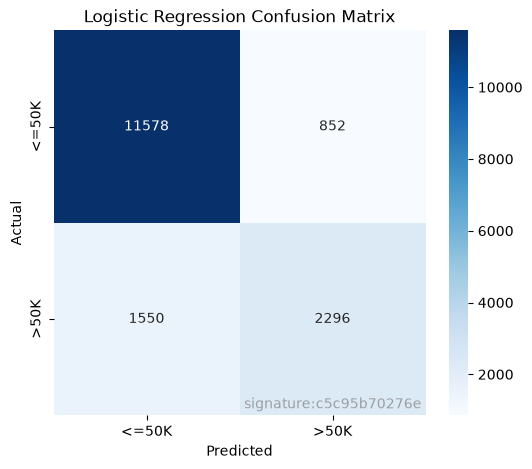

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["<=50K",">50K"],
    yticklabels=["<=50K",">50K"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.text(
    0.99,0.01,
    "signature:c5c95b70276e",
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    color="gray",
    alpha=0.7
)

plt.show()